In [117]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

### Exercise 3.1.5

In [118]:
x = np.arange(0, 10.5, 0.5)
y = np.tanh(x)

In [119]:
V = [[1, t, t * t, t * t * t] for t in x]
coeff = np.linalg.lstsq(V, y)[0]
polya = np.polynomial.Polynomial(coeff)

In [120]:
def transformIn(x):
    return (x * x) / (1. + x * x)

z = transformIn(x)
V = [[1, t, t * t, t * t * t] for t in z]
coeff = np.linalg.lstsq(V, y)[0]
polyb = lambda x : np.polynomial.Polynomial(coeff)(transformIn(x))


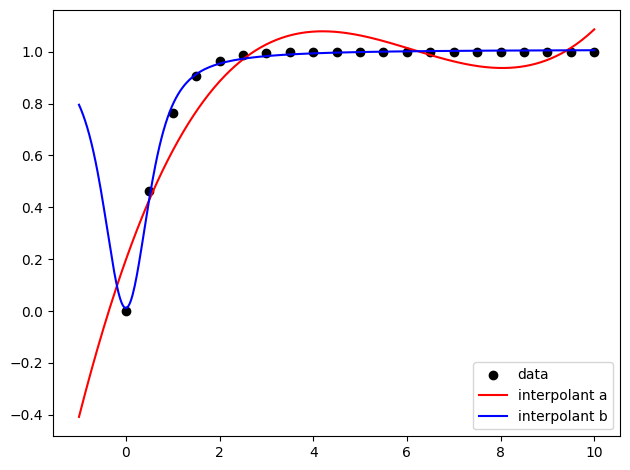

In [121]:
xx = np.linspace(-1, 10, 500)

plt.scatter(x, y, c='k', label='data')
plt.plot(xx, polya(xx), c='r', label='interpolant a')
plt.plot(xx, polyb(xx), c='b', label='interpolant b')
plt.legend()
plt.tight_layout()
plt.show()

### Exercise 3.1.6

In [122]:
k = np.arange(1, 20, dtype=np.float64)
s = scipy.special.factorial(k - 1) / np.cumprod(2 * k - 1)
s = np.cumsum(s)
e = np.abs(s - np.pi / 2)

In [123]:
V = [[1, t] for t in k]
c = np.linalg.lstsq(V, np.log(e))[0]
lna, lnb = c[0], c[1]

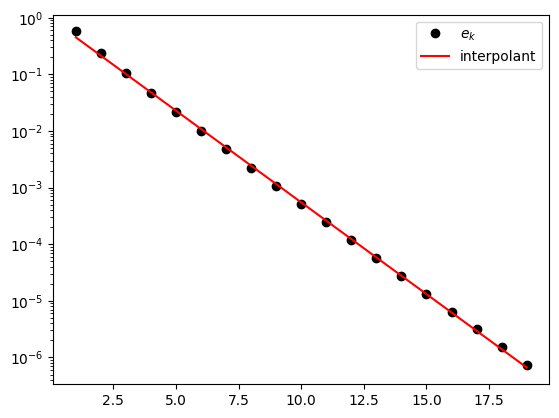

In [124]:
plt.semilogy(k, e, 'o', c='k', label='$e_k$')
plt.plot(k, np.exp(lna + lnb * k), c='r', label='interpolant')
plt.legend()
plt.show()

### Exercise 3.1.7

In [125]:
distance = np.array([
    57.9, 
    108.2, 
    149.6, 
    228.0, 
    778.5, 
    1432, 
    2867, 
    4515
])

period = np.array([
    88.0, 
    224.7, 
    365.2, 
    687.0, 
    4331, 
    10750, 
    30590, 
    59800
])

In [137]:
V = [[1, np.log(r)] for r in distance]
c = np.linalg.lstsq(V, np.log(period))[0]
lnc, a = c[0], c[1]

print(f'c = {np.exp(lnc):.3f}, alpha = {a:.3f}')

c = 0.202, alpha = 1.498


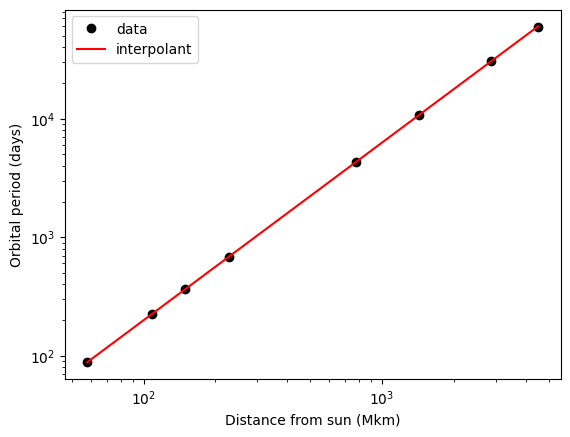

In [135]:
plt.loglog(distance, period, 'o', c='k', label='data')
plt.plot(distance, np.exp(lnc + a * np.log(distance)), c='r', label='interpolant')
plt.xlabel('Distance from sun (Mkm)')
plt.ylabel('Orbital period (days)')
plt.legend()
plt.show()